I0000 00:00:1785842219.014175  157078 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785842219.014625  157078 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785842219.051620  157078 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785842220.543750  157078 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

   PM2.5 (µg/m³)  CO (mg/m³)  AT (°C)  RH (%)  WS (m/s)  WD (deg)  \
0          95.90        1.41    15.85   95.55      0.27    118.63   
1          94.81        1.46    15.71   96.59      0.27     90.90   
2          94.12        1.47    15.66   97.10      0.25     74.32   
3          94.12        1.45    15.65   97.53      0.26     84.46   
4          94.12        1.44    15.66   97.77      0.23     89.09   

   TOT-RF (mm)  BP (mmHg)  month  weekday  hour  season  AQI_PM_2_5  AQI_CO  
0          0.0     1018.1      1        6     0       0           3       1  
1          0.0     1018.2      1        6     0       0           3       1  
2          0.0     1018.1      1        6     0       0           3       1  
3          0.0     1018.3      1        6     0       0           3       1  
4          0.0     1018.2      1        6     1       0           3       1  

Dataset Shape : (38124, 14)

Input Shape : (38124, 10)
Output Shape: (38124,)

Class Distribution
AQI_PM_2_5
0    10

E0000 00:00:1785842221.404020  157078 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,077 (137.02 KB)

 Trainable params: 35,077 (137.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
752/763 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4466 - loss: 1.2044
Epoch 1: val_loss improved from None to 1.08892, saving model to best_pm_model.keras

Epoch 1: finished saving model to best_pm_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4833 - loss: 1.1309 - val_accuracy: 0.5193 - val_loss: 1.0889 - learning_rate: 0.0010
Epoch 2/300
725/763 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5184 - loss: 1.0745
Epoch 2: val_loss improved from 1.08892 to 1.06384, saving model to best_pm_model.keras

Epoch 2: finished saving model to best_pm_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5196 - loss: 1.0690 - val_accuracy: 0.5272 - val_loss: 1.0638 - learning_rate: 0.0010
Epoch 3/300
723/763 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5282 - loss: 1.0521
Epoch 3: val_loss improved from 1.06384 to 1.04119, saving model to best_pm_model.keras

Epoch 3: finished saving model to best_pm_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 1s

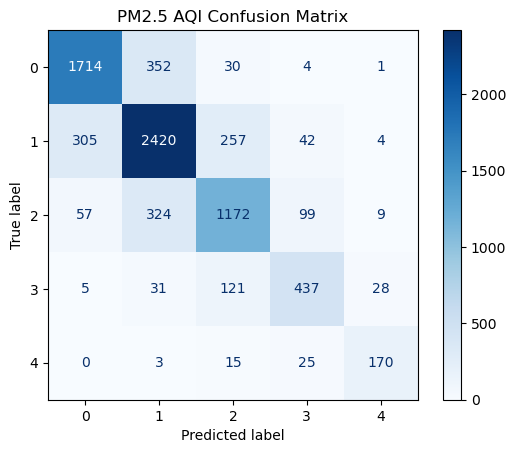

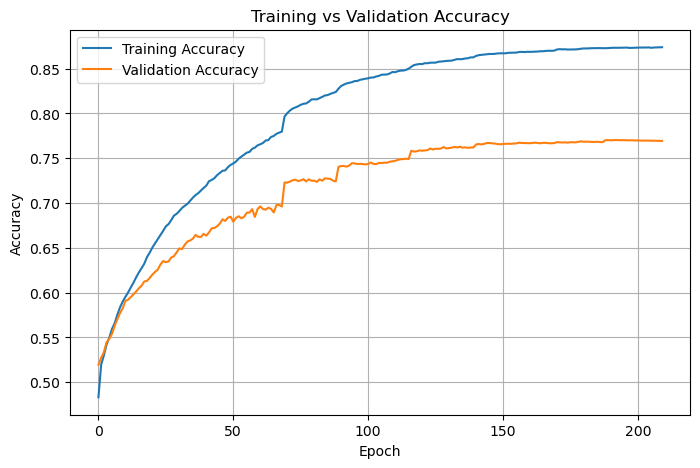

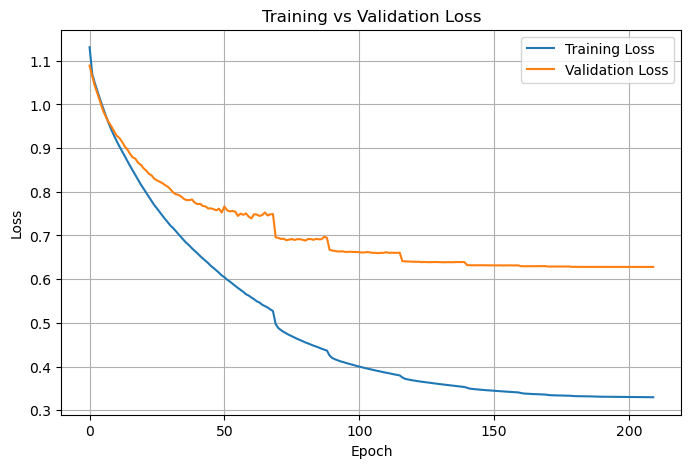

In [1]:
# ============================================================
# PM2.5 AQI Classification using MLP
#
# Input  : Meteorological Parameters
# Output : AQI_PM_2_5 (5 Classes)
#
# Class Labels
# 0 -> Good
# 1 -> Satisfactory
# 2 -> Moderate
# 3 -> Poor
# 4 -> Very Poor
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("Durgapur_Selected_Columns_4Seasons_Classification.csv")

print(df.head())

print("\nDataset Shape :", df.shape)

# ============================================================
# Input Features
# ============================================================

INPUT_FEATURES = [

    "AT (°C)",
    "RH (%)",
    "WS (m/s)",
    "WD (deg)",
    "TOT-RF (mm)",
    "BP (mmHg)",
    "month",
    "weekday",
    "hour",
    "season"

]

TARGET = "AQI_PM_2_5"

X = df[INPUT_FEATURES]
y = df[TARGET]

print("\nInput Shape :", X.shape)
print("Output Shape:", y.shape)

print("\nClass Distribution")

print(y.value_counts().sort_index())

# ============================================================
# Train/Test Split (Stratified)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y

)

# ============================================================
# Validation Split (Stratified)
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,

    test_size=0.20,

    random_state=SEED,

    stratify=y_train

)

print("\nTraining Samples :", len(X_train))
print("Validation Samples :", len(X_val))
print("Testing Samples :", len(X_test))

# ============================================================
# Feature Scaling
# ============================================================

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

joblib.dump(

    scaler,

    "scaler_pm.pkl"

)

print("\nScaler Saved.")

# ============================================================
# Build MLP Model
# ============================================================

model = Sequential()

model.add(Dense(

    128,

    activation="relu",

    input_shape=(10,)

))

model.add(Dense(

    128,

    activation="relu"

))

model.add(Dense(

    128,

    activation="relu"

))

model.add(Dense(

    5,

    activation="softmax"

))

model.summary()

# ============================================================
# Compile Model
# ============================================================

optimizer = tf.keras.optimizers.Adam(

    learning_rate=0.001

)

model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ============================================================
# Callbacks
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=8,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_pm_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

# ============================================================
# Train Model
# ============================================================

history = model.fit(

    X_train,

    y_train,

    validation_data=(

        X_val,

        y_val

    ),

    epochs=300,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1

)

print("\nTraining Finished Successfully.")

# ============================================================
# Prediction
# ============================================================

probabilities = model.predict(X_test)

y_pred = np.argmax(

    probabilities,

    axis=1

)

# ============================================================
# Evaluation Metrics
# ============================================================

accuracy = accuracy_score(

    y_test,

    y_pred

)

precision = precision_score(

    y_test,

    y_pred,

    average="weighted"

)

recall = recall_score(

    y_test,

    y_pred,

    average="weighted"

)

f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"

)

print("\n==============================")

print("TEST PERFORMANCE")

print("==============================")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        y_pred,

        digits=4

    )

)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot(

    cmap="Blues",

    values_format="d"

)

plt.title(

    "PM2.5 AQI Confusion Matrix"

)

plt.show()

# ============================================================
# Accuracy Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# Loss Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

   PM2.5 (µg/m³)  CO (mg/m³)  AT (°C)  RH (%)  WS (m/s)  WD (deg)  \
0          95.90        1.41    15.85   95.55      0.27    118.63   
1          94.81        1.46    15.71   96.59      0.27     90.90   
2          94.12        1.47    15.66   97.10      0.25     74.32   
3          94.12        1.45    15.65   97.53      0.26     84.46   
4          94.12        1.44    15.66   97.77      0.23     89.09   

   TOT-RF (mm)  BP (mmHg)  month  weekday  hour  season  AQI_PM_2_5  AQI_CO  
0          0.0     1018.1      1        6     0       0           3       1  
1          0.0     1018.2      1        6     0       0           3       1  
2          0.0     1018.1      1        6     0       0           3       1  
3          0.0     1018.3      1        6     0       0           3       1  
4          0.0     1018.2      1        6     1       0           3       1  

Dataset Shape : (38124, 14)

Input Shape : (38124, 10)
Output Shape: (38124,)

Class Distribution
AQI_CO
0    26675


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,819 (136.01 KB)

 Trainable params: 34,819 (136.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
756/763 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7302 - loss: 0.6363
Epoch 1: val_loss improved from None to 0.57623, saving model to best_co_model.keras

Epoch 1: finished saving model to best_co_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7419 - loss: 0.5999 - val_accuracy: 0.7590 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 2/300
718/763 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7536 - loss: 0.5728
Epoch 2: val_loss improved from 0.57623 to 0.55798, saving model to best_co_model.keras

Epoch 2: finished saving model to best_co_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7557 - loss: 0.5697 - val_accuracy: 0.7608 - val_loss: 0.5580 - learning_rate: 0.0010
Epoch 3/300
752/763 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7598 - loss: 0.5578
Epoch 3: val_loss improved from 0.55798 to 0.54419, saving model to best_co_model.keras

Epoch 3: finished saving model to best_co_model.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 1s

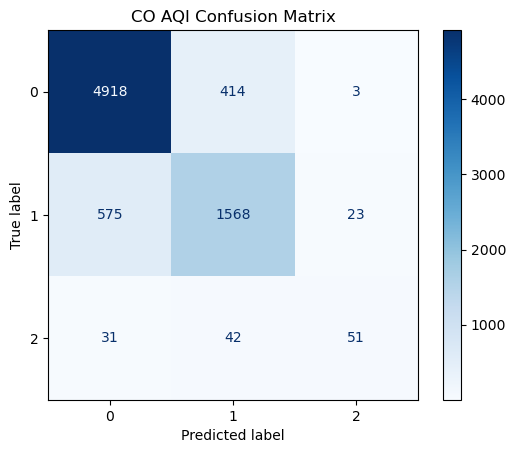

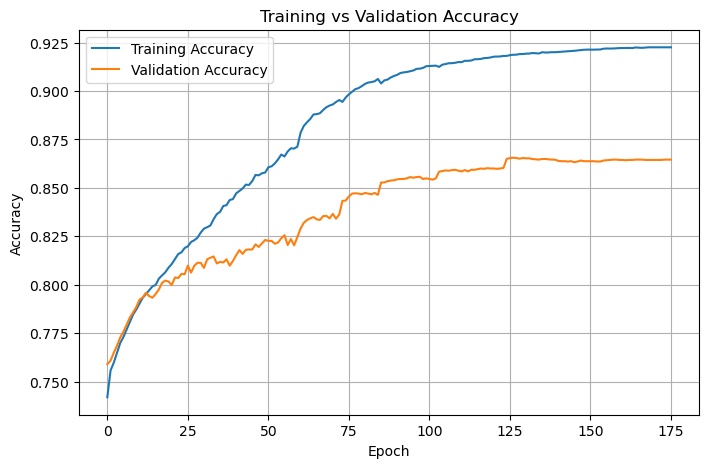

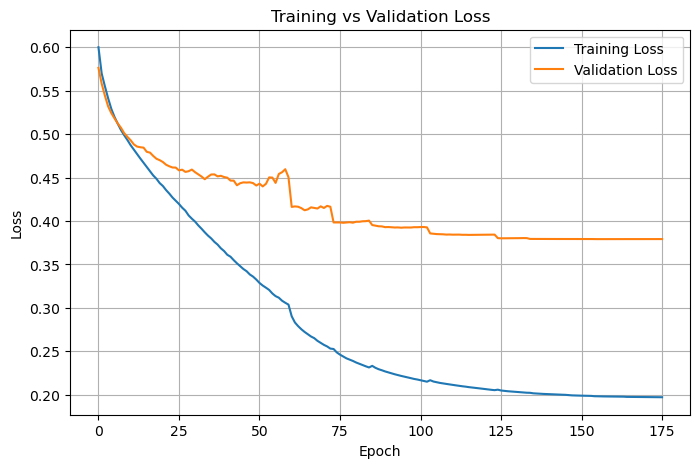

In [2]:
# ============================================================
# CO AQI Classification using MLP
#
# Input  : Meteorological Parameters
# Output : AQI_CO (3 Classes)
#
# Class Labels
# 0 -> Good
# 1 -> Satisfactory
# 2 -> Moderate
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("Durgapur_Selected_Columns_4Seasons_Classification.csv")

print(df.head())

print("\nDataset Shape :", df.shape)

# ============================================================
# Input Features
# ============================================================

INPUT_FEATURES = [

    "AT (°C)",
    "RH (%)",
    "WS (m/s)",
    "WD (deg)",
    "TOT-RF (mm)",
    "BP (mmHg)",
    "month",
    "weekday",
    "hour",
    "season"

]

TARGET = "AQI_CO"

X = df[INPUT_FEATURES]
y = df[TARGET]

print("\nInput Shape :", X.shape)
print("Output Shape:", y.shape)

print("\nClass Distribution")

print(y.value_counts().sort_index())

# ============================================================
# Train/Test Split (Stratified)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y

)

# ============================================================
# Validation Split (Stratified)
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,

    test_size=0.20,

    random_state=SEED,

    stratify=y_train

)

print("\nTraining Samples :", len(X_train))
print("Validation Samples :", len(X_val))
print("Testing Samples :", len(X_test))

# ============================================================
# Feature Scaling
# ============================================================

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

joblib.dump(

    scaler,

    "scaler_co.pkl"

)

print("\nScaler Saved.")

# ============================================================
# Build MLP Model
# ============================================================

model = Sequential()

model.add(Dense(

    128,

    activation="relu",

    input_shape=(10,)

))

model.add(Dense(

    128,

    activation="relu"

))

model.add(Dense(

    128,

    activation="relu"

))

model.add(Dense(

    3,

    activation="softmax"

))

model.summary()

# ============================================================
# Compile Model
# ============================================================

optimizer = tf.keras.optimizers.Adam(

    learning_rate=0.001

)

model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# ============================================================
# Callbacks
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=8,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_co_model.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

# ============================================================
# Train Model
# ============================================================

history = model.fit(

    X_train,

    y_train,

    validation_data=(

        X_val,

        y_val

    ),

    epochs=300,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1

)

print("\nTraining Finished Successfully.")

# ============================================================
# Prediction
# ============================================================

probabilities = model.predict(X_test)

y_pred = np.argmax(

    probabilities,

    axis=1

)

# ============================================================
# Evaluation Metrics
# ============================================================

accuracy = accuracy_score(

    y_test,

    y_pred

)

precision = precision_score(

    y_test,

    y_pred,

    average="weighted"

)

recall = recall_score(

    y_test,

    y_pred,

    average="weighted"

)

f1 = f1_score(

    y_test,

    y_pred,

    average="weighted"

)

print("\n==============================")

print("TEST PERFORMANCE")

print("==============================")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        y_pred,

        digits=4

    )

)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot(

    cmap="Blues",

    values_format="d"

)

plt.title(

    "CO AQI Confusion Matrix"

)

plt.show()

# ============================================================
# Accuracy Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# Loss Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [3]:
import tensorflow as tf

# ============================================================
# Load Keras Model
# ============================================================

model = tf.keras.models.load_model(
    "best_pm_model.keras"
)

# ============================================================
# Float32 TFLite Converter
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = []

tflite_model = converter.convert()

# ============================================================
# Save Model
# ============================================================

with open("pm_model_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("PM Float32 TFLite Model Saved.")

INFO:tensorflow:Assets written to: /tmp/tmp8bqppzx4/assets


INFO:tensorflow:Assets written to: /tmp/tmp8bqppzx4/assets


Saved artifact at '/tmp/tmp8bqppzx4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  124936370357456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370363600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370358032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370363792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370359376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370366480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370366288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936370368016: TensorSpec(shape=(), dtype=tf.resource, name=None)
PM Float32 TFLite Model Saved.


W0000 00:00:1785843140.210066  157078 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785843140.210082  157078 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1785843140.210325  157078 reader.cc:83] Reading SavedModel from: /tmp/tmp8bqppzx4
I0000 00:00:1785843140.210682  157078 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1785843140.210685  157078 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp8bqppzx4
I0000 00:00:1785843140.213401  157078 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1785843140.213845  157078 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1785843140.236662  157078 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp8bqppzx4
I0000 00:00:1785843140.242135  157078 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 31815 microseconds.
I0000 00:00:1785843140.253368  157078

In [4]:
import tensorflow as tf

# ============================================================
# Load Keras Model
# ============================================================

model = tf.keras.models.load_model(
    "best_co_model.keras"
)

# ============================================================
# Float32 TFLite Converter
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = []

tflite_model = converter.convert()

# ============================================================
# Save Model
# ============================================================

with open("co_model_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("CO Float32 TFLite Model Saved.")

INFO:tensorflow:Assets written to: /tmp/tmp_kyzh_el/assets


INFO:tensorflow:Assets written to: /tmp/tmp_kyzh_el/assets


Saved artifact at '/tmp/tmp_kyzh_el'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  124936369885584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936369881936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124937255693072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936369883664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936369892304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936369887504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936369883280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124936369881552: TensorSpec(shape=(), dtype=tf.resource, name=None)
CO Float32 TFLite Model Saved.


W0000 00:00:1785843158.881279  157078 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785843158.881294  157078 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1785843158.881410  157078 reader.cc:83] Reading SavedModel from: /tmp/tmp_kyzh_el
I0000 00:00:1785843158.881692  157078 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1785843158.881697  157078 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp_kyzh_el
I0000 00:00:1785843158.884372  157078 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1785843158.903510  157078 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp_kyzh_el
I0000 00:00:1785843158.909447  157078 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 28046 microseconds.


In [5]:
import joblib

# ============================================================
# Load Scaler
# ============================================================

scaler = joblib.load("scaler_pm.pkl")

mins = scaler.data_min_
maxs = scaler.data_max_

# ============================================================
# Write Header
# ============================================================

with open("pm_scaler.h", "w") as f:

    f.write("#ifndef PM_SCALER_H\n")
    f.write("#define PM_SCALER_H\n\n")

    f.write("#define NUM_FEATURES 10\n\n")

    f.write("static const float PM_MIN[NUM_FEATURES] = {\n")

    for i, value in enumerate(mins):

        comma = "," if i < len(mins)-1 else ""

        f.write(f"    {value:.8f}f{comma}\n")

    f.write("};\n\n")

    f.write("static const float PM_MAX[NUM_FEATURES] = {\n")

    for i, value in enumerate(maxs):

        comma = "," if i < len(maxs)-1 else ""

        f.write(f"    {value:.8f}f{comma}\n")

    f.write("};\n\n")

    f.write("""static inline void scale_PM(float x[NUM_FEATURES])
{
    for(int i=0;i<NUM_FEATURES;i++)
    {
        x[i] = (x[i] - PM_MIN[i]) /
               (PM_MAX[i] - PM_MIN[i]);
    }
}

#endif
""")

print("PM Scaler Header Generated Successfully.")

PM Scaler Header Generated Successfully.


In [6]:
import joblib

# ============================================================
# Load Scaler
# ============================================================

scaler = joblib.load("scaler_co.pkl")

mins = scaler.data_min_
maxs = scaler.data_max_

# ============================================================
# Write Header
# ============================================================

with open("co_scaler.h", "w") as f:

    f.write("#ifndef CO_SCALER_H\n")
    f.write("#define CO_SCALER_H\n\n")

    f.write("#define NUM_FEATURES 10\n\n")

    f.write("static const float CO_MIN[NUM_FEATURES] = {\n")

    for i, value in enumerate(mins):

        comma = "," if i < len(mins)-1 else ""

        f.write(f"    {value:.8f}f{comma}\n")

    f.write("};\n\n")

    f.write("static const float CO_MAX[NUM_FEATURES] = {\n")

    for i, value in enumerate(maxs):

        comma = "," if i < len(maxs)-1 else ""

        f.write(f"    {value:.8f}f{comma}\n")

    f.write("};\n\n")

    f.write("""static inline void scale_CO(float x[NUM_FEATURES])
{
    for(int i=0;i<NUM_FEATURES;i++)
    {
        x[i] = (x[i] - CO_MIN[i]) /
               (CO_MAX[i] - CO_MIN[i]);
    }
}

#endif
""")

print("CO Scaler Header Generated Successfully.")

CO Scaler Header Generated Successfully.
